In [36]:
from google.cloud import bigquery
client_bq = bigquery.Client.from_service_account_json("../credentials.json", project='charged-dialect-824')

# Loading data from BQ

In [37]:
def load_bq_data(_sql):
    _df = client_bq.query(_sql).to_dataframe()
    return _df

In [38]:
sql = """
SELECT *
FROM RicardoInterview.product_detection_training_data
"""

df_load = load_bq_data(sql)
len(df_load)
df_load.head()

/home/vankhoa@median.cad/code/github/di-interview-product-classifier/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1933: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,articleId,title,subtitle,productType
0,-3393892867263864215,Gone Is Gone - Echolocation,Gone Is Gone - Echolocation,cd
1,-2831118468819601923,Ekseption-The Lost Last Concert Tapes...,The Lost Last Concert Tapes (Box-Set),cd
2,6835807414137785977,PORTISHEAD CD-Sammlung 3 CDs #16,Kollektion für Fans der Trip-Hop-Pioniere aus ...,cd
3,-4912458353746230865,Primeon CD-R Rohlinge (bunt),39 Stück auf der Spindel,cd
4,1496864991301777371,Adonia - Zmittst im Füür,Markus Hottiger / Markus Heusser,cd


# To be implemented

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score
import datetime
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, BertModel
from tqdm import tqdm
from sklearn.manifold import TSNE
from datetime import datetime
    

## Data Cleaning

This section performs text preprocessing and analysis on the title, subtitle, and productType columns to prepare the dataset for further modeling or analysis.

In [40]:
# 1. Initial Shape Check
print(f'Before cleaning: {df_load.shape}')

# 2. Combine Text Fields
df_load['combined_text'] = df_load['title'] + ' ' + df_load['subtitle']

# 3. Text Length Calculation
df_load['title_length'] = df_load['title'].apply(len)
df_load['subtitle_length'] = df_load['subtitle'].apply(len)
df_load['combined_length'] = df_load['combined_text'].apply(len)

# 4. Set all to lowercase and remove non-alphanumeric characters
df_load['subtitle'] = df_load['subtitle'].str.lower().str.replace('[^\w\s]', '', regex=True).fillna('')

# 5. Remove rows with empty title or subtitle
df_load = df_load[df_load['title'].notna() & df_load['subtitle'].notna()]
df_load = df_load[df_load['productType'].notna()]
df_load = df_load[df_load['title'] != '']
df_load = df_load[df_load['productType'] != '']

# 6. Trim Whitespace
df_load['title'] = df_load['title'].str.strip()
df_load['subtitle'] = df_load['subtitle'].str.strip()
df_load['productType'] = df_load['productType'].str.strip()


# 7. Final Shape Check
print(f'After cleaning: {df_load.shape}')

Before cleaning: (37567, 4)
After cleaning: (37565, 8)


## Analysis

productType
radio_controlled_model    99
cd                        99
pc                        99
wc                        99
bag                       99
                          ..
holster                   63
handrail                  61
jukebox                   60
dump_truck                52
marble                    48
Name: count, Length: 383, dtype: int64


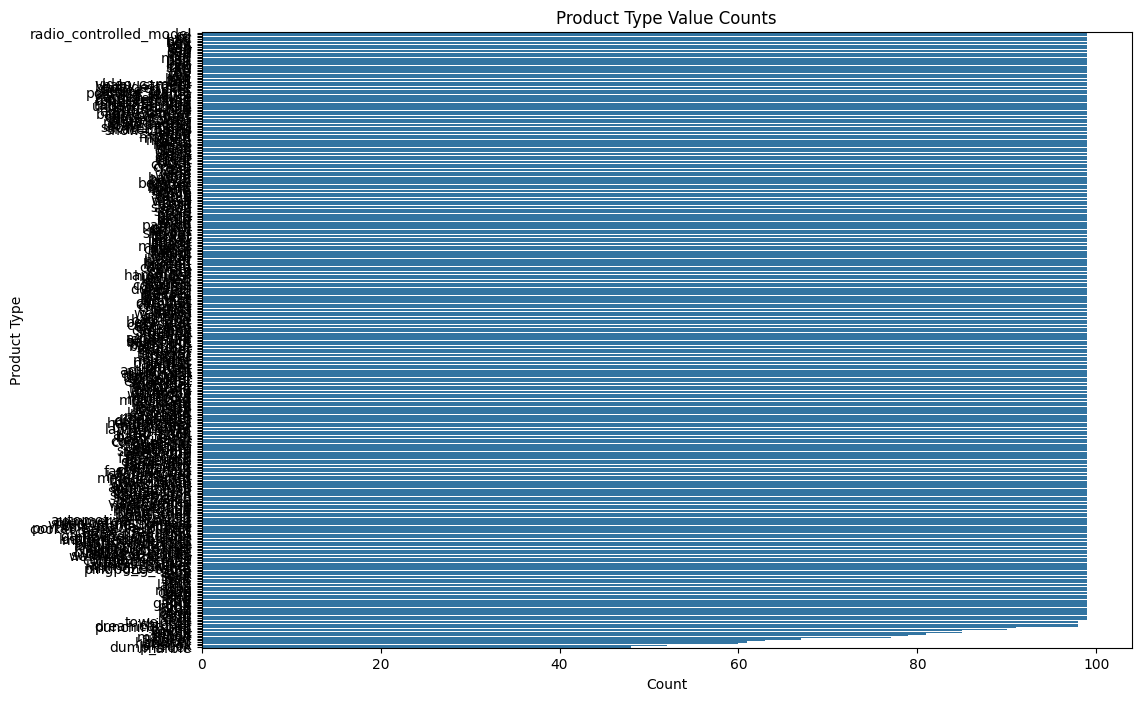

In [63]:
print(df_load['productType'].value_counts())

# plot the value counts
plt.figure(figsize=(12, 8))
sns.barplot(y=df_load['productType'].value_counts().index, x=df_load['productType'].value_counts().values)
plt.title('Product Type Value Counts')
plt.xlabel('Count')
plt.ylabel('Product Type')
plt.savefig('product_type_value_counts.png')

1. There are high amount of classes (383 product types), which makes the classification harder for simple models like logistic regression or simple neural nets --> transformer based model.
2. Class imbalance issue, could leads to poor generalization on small classes.
3. Limit information from title alone, in real dataset there should be more features

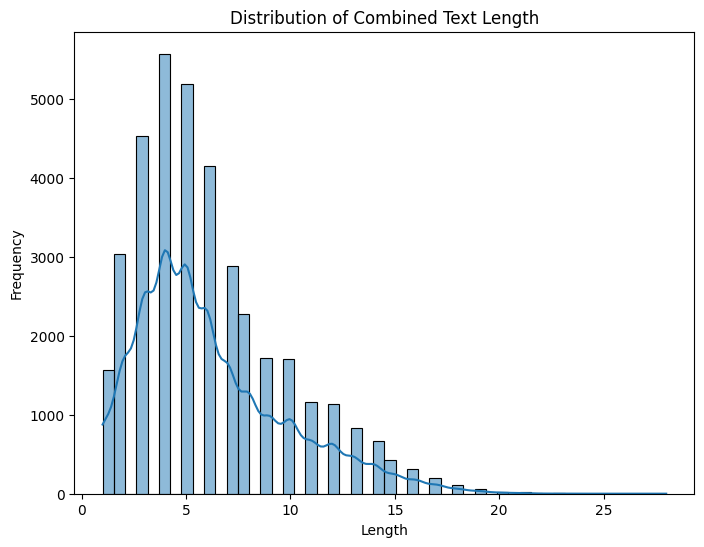

In [69]:
# 2. Number of words in combined text
df_load['combined_length'] = df_load['combined_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 6))
sns.histplot(df_load['combined_length'], bins=50, kde=True)
plt.title('Distribution of Combined Text Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.savefig('combined_length_distribution.png')
plt.show()

- The distribution is right skewed, most of the product titles are short.
- The max length should be around 100 characters to avoid wasting computation.

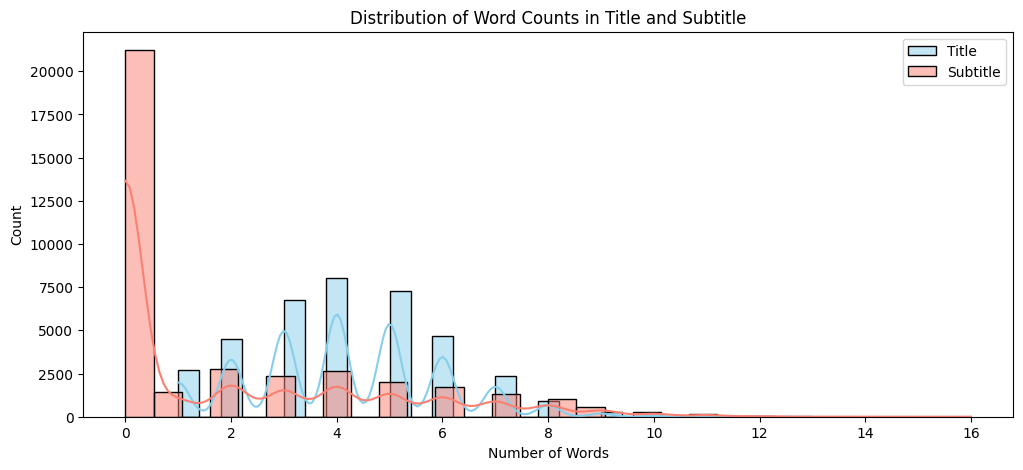

In [65]:
df_load['title_length'] = df_load['title'].apply(lambda x: len(str(x).split()))
df_load['subtitle_length'] = df_load['subtitle'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))
sns.histplot(df_load['title_length'], bins=30, color='skyblue', label='Title', kde=True)
sns.histplot(df_load['subtitle_length'], bins=30, color='salmon', label='Subtitle', kde=True)
plt.legend()
plt.title("Distribution of Word Counts in Title and Subtitle")
plt.xlabel("Number of Words")
plt.savefig('word_counts_distribution.png')
plt.show()

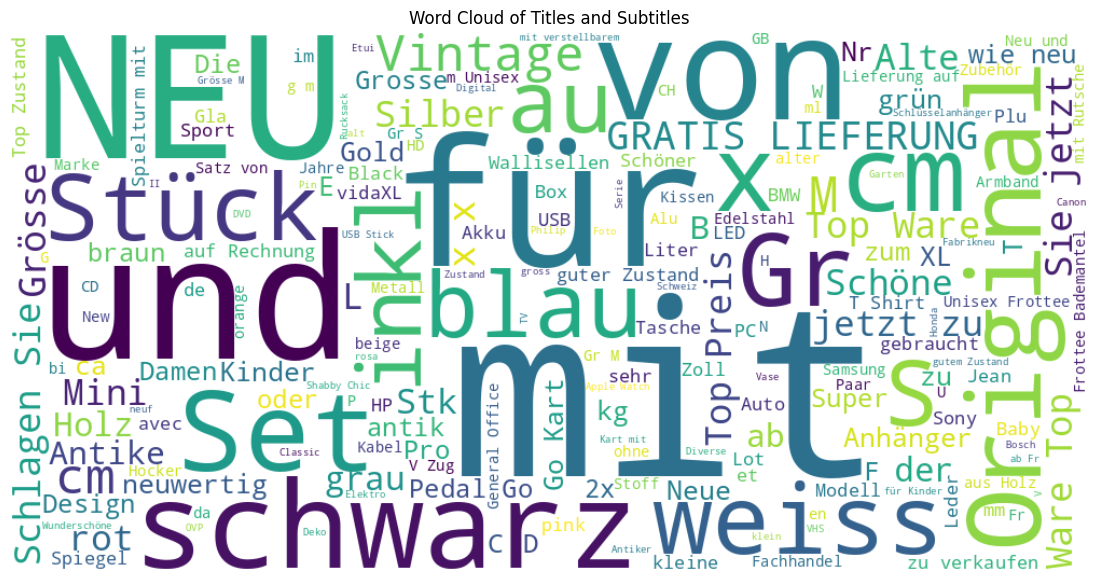

In [66]:
from wordcloud import WordCloud

text = ' '.join(df_load['combined_text'].dropna().values)

wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Titles and Subtitles")
plt.savefig('word_cloud.png')
plt.show()

/home/vankhoa@median.cad/code/github/di-interview-product-classifier/venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


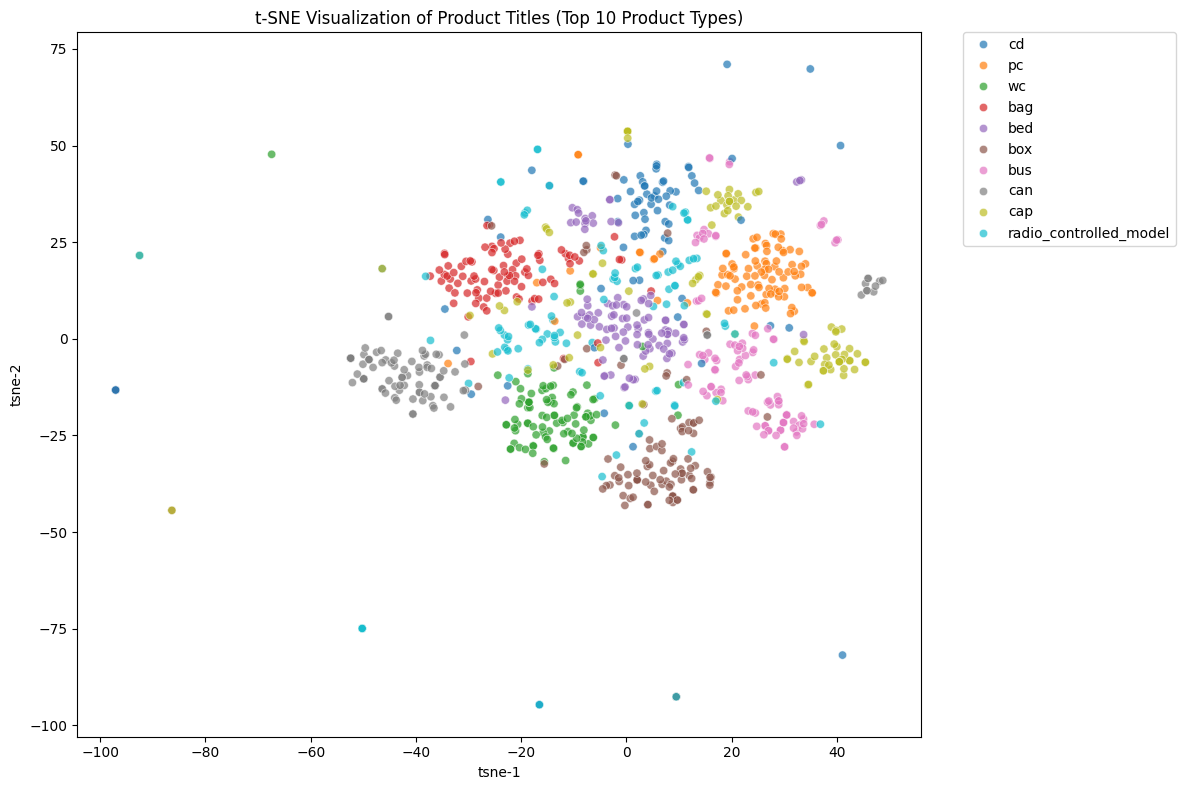

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# Filter to top 10 classes
top_classes = df_load['productType'].value_counts().head(10).index
df_vis = df_load[df_load['productType'].isin(top_classes)]

# Vectorize titles
tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
X_tfidf = tfidf.fit_transform(df_vis['combined_text'].fillna(""))

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_tfidf.toarray())

# Create DataFrame for plotting
df_plot = pd.DataFrame()
df_plot['tsne-1'] = X_tsne[:, 0]
df_plot['tsne-2'] = X_tsne[:, 1]
df_plot['productType'] = df_vis['productType'].values

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="tsne-1", y="tsne-2",
    hue="productType",
    palette="tab10",
    data=df_plot,
    alpha=0.7
)
plt.title("t-SNE Visualization of Product Titles (Top 10 Product Types)")
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.tight_layout()
plt.savefig('tsne_visualization.png')
plt.show()

/home/vankhoa@median.cad/singularity/ipykernel_1100494/3723643209.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_bert.groupby('productType').apply(lambda x: x.sample(min(100, len(x)), random_state=42)).reset_index(drop=True)
Embedding with BERT: 100%|██████████| 990/990 [01:07<00:00, 14.60it/s]
/home/vankhoa@median.cad/code/github/di-interview-product-classifier/venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


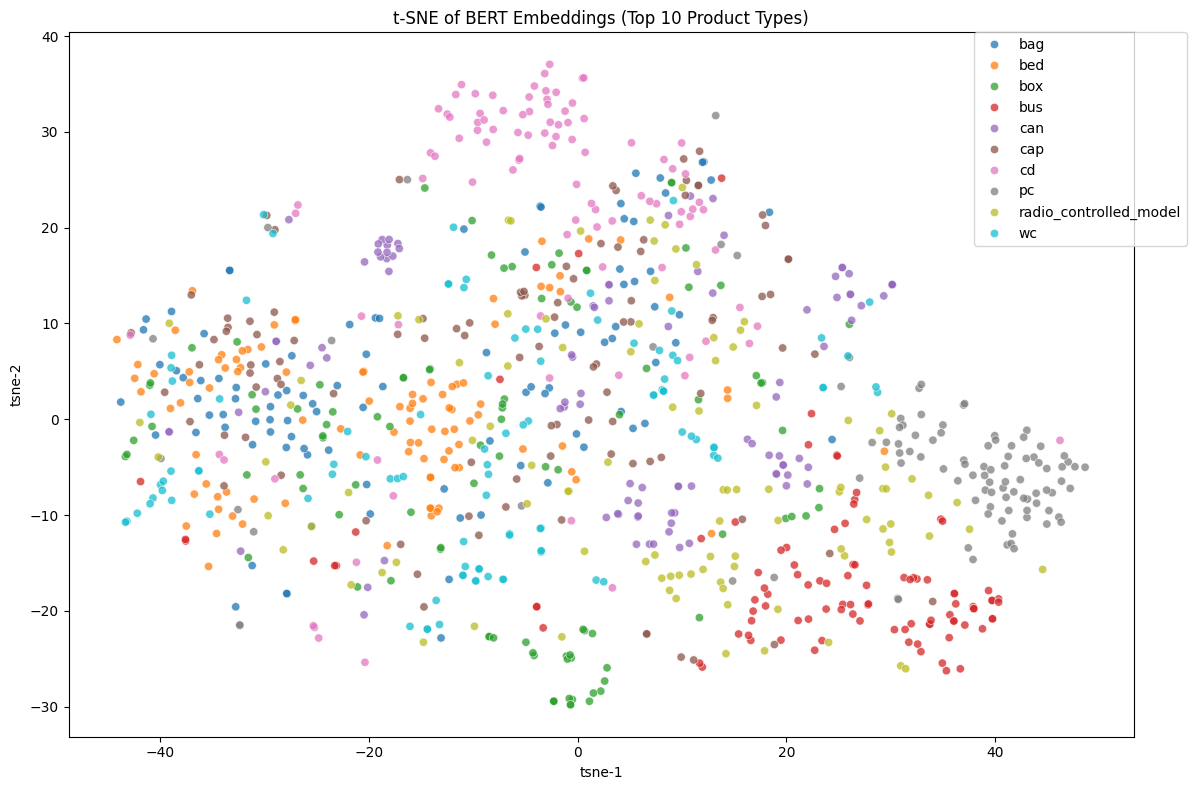

In [68]:
# Load model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

def get_bert_embedding(text):
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=32)
        outputs = model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        return cls_embedding.squeeze().numpy()
    
# Focus on top 10 product types
top_classes = df_load['productType'].value_counts().head(10).index
df_bert = df_load[df_load['productType'].isin(top_classes)].dropna(subset=['combined_text'])

# Sample max 100 items per class for speed
df_sampled = df_bert.groupby('productType').apply(lambda x: x.sample(min(100, len(x)), random_state=42)).reset_index(drop=True)

# Generate embeddings
embeddings = []
for text in tqdm(df_sampled['combined_text'], desc="Embedding with BERT"):
    embeddings.append(get_bert_embedding(text))

embeddings_array = np.array(embeddings)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(embeddings_array)

# Prepare DataFrame
df_tsne = pd.DataFrame(X_tsne, columns=['tsne-1', 'tsne-2'])
df_tsne['productType'] = df_sampled['productType'].values

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="tsne-1", y="tsne-2",
    hue="productType",
    palette="tab10",
    data=df_tsne,
    alpha=0.75
)
plt.title("t-SNE of BERT Embeddings (Top 10 Product Types)")
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.tight_layout()
plt.savefig('tsne_visualization_bert.png')
plt.show()

In [47]:
# 1. Encode labels
le = LabelEncoder()
df_load['productType_encoded'] = le.fit_transform(df_load['productType'])

In [48]:
# 2. Train-Test Split
# Split data into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(
    df_load['combined_text'],
    df_load['productType_encoded'],
    test_size=0.2,
    stratify=df_load['productType_encoded'],
    random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1,  # 10% of the remaining 80% (i.e., 8% of total)
    stratify=y_temp,
    random_state=42
)

In [ ]:
# Baseline model
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=10000)),
    ('clf', LogisticRegression(max_iter=5000, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))

# calculate top 3 accuracy
top3_correct = 0
total = 0

print(len(y_test))
print(len(y_pred))



for i in range(len(y_test)):
    # get top 3 predictions
    print(X_test)
    y_pred_top3 = pipeline.predict_proba(X_test[i])
    y_pred_top3 = np.argsort(y_pred_top3, axis=1)[:, -3:]

    if y_test[i] in y_pred_top3:
        top3_correct += 1
    total += 1

top3_acc = top3_correct / total
print(f"Top-3 Accuracy: {top3_acc}")


Accuracy: 0.6784240649540796
F1 Score: 0.6887942901448066
Precision: 0.7235435019189156
Recall: 0.6784240649540796
7513
7513


KeyError: 0

## Model Training

In [50]:
# 3. Initialize tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
tokenizer.padding_side = 'right'
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(df_load['productType'].unique()))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [51]:
# 4. Tokenize and prepare datasets
class ProductDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)
    
# Tokenize data
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=110)
val_encodings = tokenizer(list(X_val), truncation=True, padding=True, max_length=110)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=110)

train_dataset = ProductDataset(train_encodings, y_train.tolist())
val_dataset = ProductDataset(val_encodings, y_val.tolist())
test_dataset = ProductDataset(test_encodings, y_test.tolist())

In [52]:
# Show first 5 samples
for i in range(5):
    print(train_dataset[i]['labels'])
    print(train_dataset[i]['input_ids'])
    print(train_dataset[i]['attention_mask'])

tensor(286)
tensor([  101,  2434, 20383,  2239,  3847, 13523,  1004,  3104,  1011,   102,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor(82)
tensor([  101, 12880, 13328,  1011, 24646,  7317,  2063,  2011, 12098,  2638,
        12988,  2368,   102,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0

In [53]:
# 5. Training Arguments
training_args = TrainingArguments(
    output_dir='./results', # Directory to save the model checkpoints
    num_train_epochs=30,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs', # Directory to save logs (tensorboard)
    logging_steps=100,
    save_steps=100,
    save_total_limit=2,
    eval_steps=500,
    eval_strategy="steps"
)

def compute_metrics(eval_pred):
    """
    The function that will be used to compute metrics at evaluation.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    f1 = f1_score(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    prec = precision_score(labels, predictions, average='weighted')
    rec = recall_score(labels, predictions, average='weighted')
    return {'f1': f1, 'acc': acc, 'prec': prec, 'rec': rec}

# 6. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# 7. Train the model
trainer.train()

Step,Training Loss,Validation Loss,F1,Acc,Prec,Rec
500,5.756700,5.633647,0.020038,0.045243,0.026280,0.045243
1000,4.960100,4.788888,0.133729,0.191949,0.155029,0.191949
1500,4.170800,3.944523,0.304843,0.367931,0.334980,0.367931
2000,3.282600,3.191735,0.451216,0.501996,0.485140,0.501996
2500,2.728600,2.678707,0.532602,0.567199,0.575782,0.567199
3000,2.285000,2.264816,0.622311,0.636727,0.663454,0.636727
3500,1.686200,1.964188,0.648859,0.664671,0.676540,0.664671
4000,1.453500,1.772176,0.682765,0.693280,0.717208,0.693280
4500,1.391900,1.654572,0.693351,0.701264,0.726411,0.701264
5000,1.245300,1.618378,0.705689,0.708583,0.742253,0.708583


/home/vankhoa@median.cad/code/github/di-interview-product-classifier/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vankhoa@median.cad/code/github/di-interview-product-classifier/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vankhoa@median.cad/code/github/di-interview-product-classifier/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicte

TrainOutput(global_step=50730, training_loss=0.38440234687950103, metrics={'train_runtime': 14912.3835, 'train_samples_per_second': 54.41, 'train_steps_per_second': 3.402, 'total_flos': 2.51031258483192e+16, 'train_loss': 0.38440234687950103, 'epoch': 30.0})

In [56]:
datetime_str = datetime.now().strftime("%Y%m%d_%H%M%S")
# Save model
model.save_pretrained(f'bert-base-uncased-finetuned-product-detection-{datetime_str}')
tokenizer.save_pretrained(f'bert-base-uncased-finetuned-product-detection-{datetime_str}')

('bert-base-uncased-finetuned-product-detection-20250510_144852/tokenizer_config.json',
 'bert-base-uncased-finetuned-product-detection-20250510_144852/special_tokens_map.json',
 'bert-base-uncased-finetuned-product-detection-20250510_144852/vocab.txt',
 'bert-base-uncased-finetuned-product-detection-20250510_144852/added_tokens.json')

## Evaluation

In [59]:
# Load model
model_loaded = BertForSequenceClassification.from_pretrained('bert-base-uncased-finetuned-product-detection-20250510_144852')
tokenizer_loaded = BertTokenizer.from_pretrained('bert-base-uncased-finetuned-product-detection-20250510_144852')

In [60]:
# DataLoader for batching
test_loader = DataLoader(test_dataset, batch_size=16)

model.eval()
all_preds = []
top3_correct = 0
total = 0

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader)):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']
        outputs = model_loaded(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Top-1 predictions
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

        # Top-3 predictions
        top3 = torch.topk(logits, k=3, dim=1).indices.cpu().numpy()
        labels_np = labels.cpu().numpy()
        for i in range(labels_np.shape[0]):
            if labels_np[i] in top3[i]:
                top3_correct += 1
            total += 1

100%|██████████| 470/470 [13:51<00:00,  1.77s/it]


In [61]:
# Standard metrics for top-1
f1 = f1_score(y_test, all_preds, average='weighted')
acc = accuracy_score(y_test, all_preds)
prec = precision_score(y_test, all_preds, average='weighted')
rec = recall_score(y_test, all_preds, average='weighted')

# Top-3 accuracy
top3_acc = top3_correct / total
print(f"F1 score: {f1}")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"Top-3 Accuracy: {top3_acc}")

F1 score: 0.7807051155506471
Accuracy: 0.7802475708771462
Precision: 0.7917852373878892
Recall: 0.7802475708771462
Top-3 Accuracy: 0.8401437508318914
